# Stochastic Block Modeling of Hippocampal Connectivity

**Central question:** *How do connectivity profiles **leaving** the hippocampus differ
from profiles **entering** it?* (efferent vs afferent)

This notebook runs two analyses on the Swanson et al. (2024) bilateral rat connectome:

1. **Part 1 — Bipartite SBM (exploratory):** group the partner regions by their
   7-dimensional hippocampal connectivity profile, separately for **efferent**
   (HPC → partner) and **afferent** (partner → HPC) connections.
2. **Part 2 — Directed 79×79 SBM (primary):** a single *directed* block model whose
   **asymmetric** block-affinity matrix captures send-vs-receive structure in one model.

We use **graph-tool** (Peixoto's framework): inference by MCMC + **Minimum Description
Length (MDL)**, which *infers* the number of blocks instead of requiring a manual scan
over `k`.

> The full conceptual background for everything below lives in `../SBM_concepts.md`.

## What is a Stochastic Block Model?

An SBM is a **generative model of a network**. Its single core assumption:

> Every node secretly belongs to one of `B` latent groups ("blocks"). The probability
> (and weight) of a connection between two nodes depends **only on which blocks they
> belong to** — not on the nodes' individual identities.

So the model has two ingredients:

1. a **block label** for every node (which group it is in), and
2. a **`B × B` affinity matrix** (call it **ω**) giving the expected edge weight from
   block *r* to block *s*.

**Fitting** an SBM means running that generator *in reverse*: given the wiring we
actually observed, find the block labels (and ω) that most plausibly produced it.

**Why an SBM beats ordinary community detection.** Modularity-based methods (like the
spectral / consensus clustering elsewhere in this repo) can only find *assortative*
groups — clumps that connect densely *within* themselves. An SBM can recover **any**
pattern: assortative, **disassortative** (groups that avoid each other), **core–periphery**,
and hierarchical. Think of it as inferring latent *cell types* from a wiring diagram —
you don't pre-define the types; the connectivity reveals which nodes are interchangeable.

**Why we don't pick the number of blocks.** graph-tool minimizes a *description length*:
more blocks fit better but cost more to describe. MDL balances the two and stops adding
blocks once they stop compressing the data — so the block count is **inferred for us**.

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import graph_tool.all as gt
from sklearn.metrics import adjusted_mutual_info_score

from helpers import log_weight_transform, get_feature_vectors_shared_hpc

# Reproducibility
np.random.seed(42)
gt.seed_rng(42)

hippocampal_regions = ['DG', 'CA3', 'CA2', 'CA1v', 'CA1d', 'SUBv', 'SUBd']

df_average = pd.read_csv('../data/average_connectome_data.csv', header=0, index_col=0)
print('Connectome matrix:', df_average.shape)
print('Ordinal weight range:', np.nanmin(df_average.values), '-', np.nanmax(df_average.values))

Connectome matrix: (392, 392)
Ordinal weight range: 0.0 - 7.0


### Reusable fitting helpers

Both analyses share the same two steps, so we define them once:

- **`build_*_graph`** — turn a weighted matrix into a graph-tool `Graph`, keeping the
  (already log-transformed) connection weights as an edge property.
- **`fit_sbm_consensus`** — fit the SBM by MDL, then run an MCMC chain and aggregate
  many sampled partitions into a single **consensus** partition. A single MDL fit is one
  point estimate; the MCMC consensus is more robust because it summarizes the *landscape*
  of good partitions (this is graph-tool's analogue of the Faskowitz consensus workflow).

The weight model is `real-exponential`: our log-transformed weights are **positive and
skewed**, which the exponential family models far better than a Gaussian would. Only
non-zero entries become edges, so an ordinal-0 is a true **non-edge** (not a weight-0
edge) — keeping the edge-existence and edge-weight parts of the model clean.

In [61]:
def fit_sbm_consensus(g, pclabel=None, n_collect=1500, burn_wait=1000):
    # Fit a (possibly bipartite / directed) weighted SBM, return a consensus partition.
    # Returns (state, b_consensus, marginal, pmode):
    #   state       : graph-tool BlockState from the initial MDL fit
    #   b_consensus : VertexPropertyMap of consensus block labels
    #   marginal    : per-node marginal block distribution
    #   pmode       : PartitionModeState (landscape summary)
    state_args = dict(recs=[g.ep['weight']], rec_types=['real-exponential'])
    if pclabel is not None:
        state_args['pclabel'] = pclabel

    # 1. Point estimate by Minimum Description Length (infers the block count).
    state = gt.minimize_blockmodel_dl(g, state_args=state_args)

    # 2. Burn in the MCMC chain.
    gt.mcmc_equilibrate(state, wait=burn_wait, mcmc_args=dict(niter=10))

    # 3. Collect many partitions from the equilibrated chain.
    partitions = []
    gt.mcmc_equilibrate(state, force_niter=n_collect, mcmc_args=dict(niter=10),
                        callback=lambda s: partitions.append(s.b.a.copy()))

    # 4. Summarize the landscape into a single consensus partition.
    pmode = gt.PartitionModeState(partitions, converge=True)
    b_consensus = pmode.get_max(g)
    marginal = pmode.get_marginal(g)
    return state, b_consensus, marginal, pmode

---
## Part 1 — Bipartite SBM (exploratory)

A **bipartite** network has two *kinds* of node with edges only **between** the kinds.
The efferent matrix is exactly this: **7 hippocampal subregions** on one side and the
**shared partner regions** on the other, with edges = HPC → partner weights.

A **bipartite SBM** (a.k.a. co-clustering) respects that structure: it finds blocks of
HPC regions **and** blocks of partner regions *simultaneously*. We enforce it with a
`pclabel` (a per-node "type" tag: `0` = HPC, `1` = partner) so a block can never mix the
two types.

We fit it **twice** — once on efferent (HPC → partner) and once on afferent
(partner → HPC) connections — over the **same shared partner set**, then ask whether the
partner regions group differently depending on direction.

**Expect:** the HPC side is only 7 nodes, so it will form just ~1–3 coarse blocks (e.g.
it may separate DG/CA3 from CA1/SUB). The interesting output is the *partner* grouping.

In [62]:
# get_feature_vectors_shared_hpc() returns (afferent, efferent) over the SHARED partners.
#   df_efferent[hpc, partner] = weight FROM hpc  TO  partner   (hippocampus SENDS)
#   df_afferent[hpc, partner] = weight FROM partner TO hpc     (hippocampus RECEIVES)
df_afferent, df_efferent = get_feature_vectors_shared_hpc()

assert list(df_efferent.columns) == list(df_afferent.columns), 'partner sets must match'
assert list(df_efferent.index) == hippocampal_regions

partner_regions = list(df_efferent.columns)
print('efferent (HPC->partner):', df_efferent.shape)
print('afferent (partner->HPC):', df_afferent.shape)
print('shared partner regions :', len(partner_regions))

# Ordinal 0-7  ->  tapered log-weighted scale (Faskowitz & Sporns 2020).
eff_w = log_weight_transform(df_efferent.values)   # 7 x S
aff_w = log_weight_transform(df_afferent.values)   # 7 x S

efferent (HPC->partner): (7, 72)
afferent (partner->HPC): (7, 72)
shared partner regions : 72


In [63]:
def build_bipartite_graph(weight_matrix, row_labels, col_labels):
    # Bipartite weighted graph: rows (HPC, kind=0) <-> cols (partners, kind=1).
    g = gt.Graph(directed=False)
    name = g.new_vp('string')
    kind = g.new_vp('int')        # pclabel: 0 = HPC, 1 = partner
    weight = g.new_ep('double')

    R, C = weight_matrix.shape
    row_v = [g.add_vertex() for _ in range(R)]
    col_v = [g.add_vertex() for _ in range(C)]
    for i, v in enumerate(row_v):
        name[v] = row_labels[i]; kind[v] = 0
    for j, v in enumerate(col_v):
        name[v] = col_labels[j]; kind[v] = 1

    for i in range(R):
        for j in range(C):
            w = weight_matrix[i, j]
            if w > 0:                       # only real connections become edges
                e = g.add_edge(row_v[i], col_v[j])
                weight[e] = w

    g.vp['name'] = name; g.vp['kind'] = kind; g.ep['weight'] = weight
    return g

g_eff = build_bipartite_graph(eff_w, hippocampal_regions, partner_regions)
g_aff = build_bipartite_graph(aff_w, hippocampal_regions, partner_regions)
print('efferent graph:', g_eff.num_vertices(), 'nodes,', g_eff.num_edges(), 'edges')
print('afferent graph:', g_aff.num_vertices(), 'nodes,', g_aff.num_edges(), 'edges')

efferent graph: 79 nodes, 185 edges
afferent graph: 79 nodes, 231 edges


In [64]:
state_eff, b_eff, pv_eff, pm_eff = fit_sbm_consensus(g_eff, pclabel=g_eff.vp['kind'])
state_aff, b_aff, pv_aff, pm_aff = fit_sbm_consensus(g_aff, pclabel=g_aff.vp['kind'])

def block_counts(g, b):
    hpc = {int(b[v]) for v in g.vertices() if g.vp['kind'][v] == 0}
    par = {int(b[v]) for v in g.vertices() if g.vp['kind'][v] == 1}
    return len(hpc), len(par)

print('efferent: %d HPC-blocks, %d partner-blocks' % block_counts(g_eff, b_eff))
print('afferent: %d HPC-blocks, %d partner-blocks' % block_counts(g_aff, b_aff))

efferent: 3 HPC-blocks, 4 partner-blocks
afferent: 2 HPC-blocks, 4 partner-blocks


### Minimum description length of each bipartite fit

graph-tool's `BlockState.entropy()` **is** the description length (in nats) that
`minimize_blockmodel_dl` minimizes, so it is the natural MDL for a fit. One subtlety: inside
`fit_sbm_consensus`, `mcmc_equilibrate` moves the returned `state` objects off the consensus
partition, so `state_eff.entropy()` would report a random MCMC *sample*, not the consensus we
actually use. The clean fix is to **rebuild a `BlockState` on the consensus labels** (same
weighted model + bipartite `pclabel`) and take its entropy.

(The values are negative — expected for the continuous `real-exponential` weight model; only
*relative* description lengths are meaningful, e.g. comparing partitions of the same graph.)

In [65]:
def consensus_description_length(g, b):
    # MDL (description length, nats) of partition b on graph g, under the same weighted
    # bipartite model used for the fit. Rebuild the state because mcmc_equilibrate moved
    # the original `state_eff` / `state_aff` off the consensus partition.
    state = gt.BlockState(g, b=b, recs=[g.ep['weight']], rec_types=['real-exponential'],
                          pclabel=g.vp['kind'])
    return state.entropy()

dl_eff = consensus_description_length(g_eff, b_eff)
dl_aff = consensus_description_length(g_aff, b_aff)
print(f'Efferent bipartite SBM: description length = {dl_eff:.3f} nats')
print(f'Afferent bipartite SBM: description length = {dl_aff:.3f} nats')

Efferent bipartite SBM: description length = -30.713 nats
Afferent bipartite SBM: description length = -400.520 nats


### Block-affinity matrices for the bipartite fits

Just as Part 2 reads structure off a block-affinity matrix **ω**, we can summarize each
bipartite fit the same way: the mean log-weight between every **HPC-block** and every
**partner-block**. Because these graphs are *bipartite*, the only populated block-pairs
are HPC↔partner, so ω is naturally a **(HPC-block × partner-block)** rectangle rather than
a square.

- **Efferent** `ω[HPC → partner]` — how strongly each HPC-block *sends* to each partner-block.
- **Afferent** `ω[partner → HPC]` — how strongly each partner-block *sends* to each HPC-block
  (i.e. what the hippocampus *receives*).

Both use the same **all-cells mean** convention as Part 2's ω (non-edges count as 0, so the
value blends how *densely* and how *strongly* two blocks connect). Reading the two together
previews the send-vs-receive story Part 2 models jointly: a partner-block that lights up in
one direction but not the other is one the hippocampus talks to but doesn't hear back from.

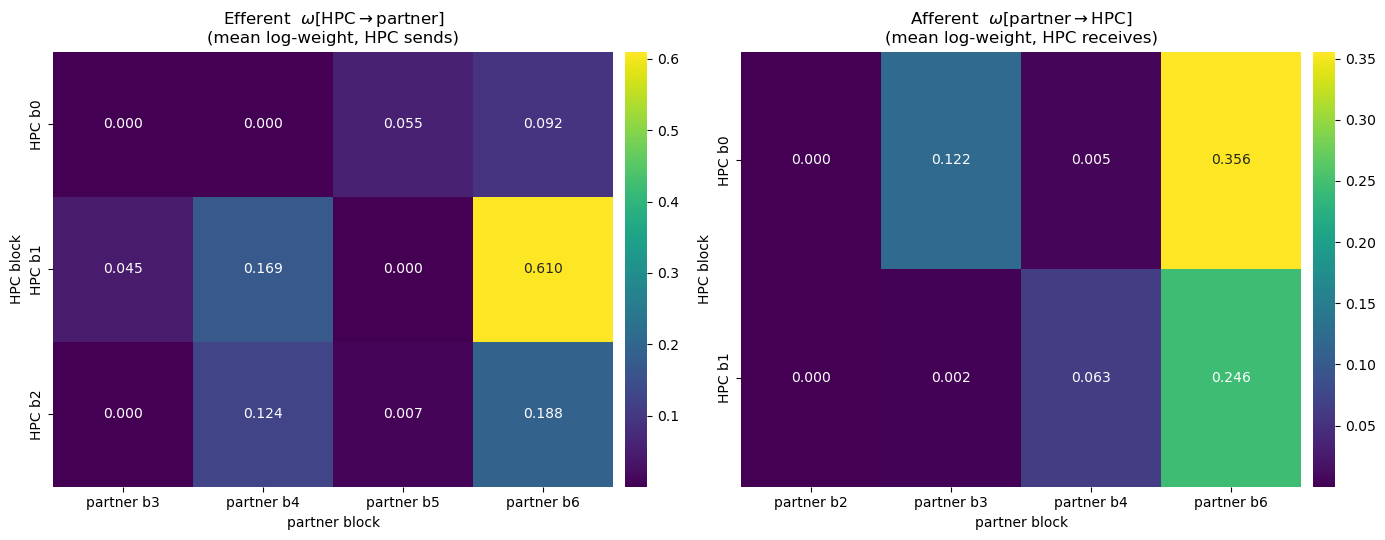

Efferent bipartite affinity (HPC-block x partner-block):
        partner b3  partner b4  partner b5  partner b6
HPC b0      0.0004      0.0002      0.0554      0.0924
HPC b1      0.0448      0.1689      0.0004      0.6100
HPC b2      0.0002      0.1236      0.0071      0.1884

Afferent bipartite affinity (HPC-block x partner-block):
        partner b2  partner b3  partner b4  partner b6
HPC b0      0.0002      0.1222      0.0054      0.3555
HPC b1      0.0001      0.0016      0.0627      0.2458


In [40]:
def bipartite_block_affinity(g, b, W, hpc_labels, partner_labels):
    # All-cells mean log-weight between each HPC-block and each partner-block.
    # W is the (n_hpc x n_partner) biadjacency: rows follow hpc_labels, cols follow partner_labels.
    idx_hpc = {r: i for i, r in enumerate(hpc_labels)}
    idx_par = {r: j for j, r in enumerate(partner_labels)}
    hpc_block, par_block = {}, {}
    for v in g.vertices():
        nm = g.vp['name'][v]
        (hpc_block if g.vp['kind'][v] == 0 else par_block)[nm] = int(b[v])

    hpc_bids = sorted(set(hpc_block.values()))
    par_bids = sorted(set(par_block.values()))
    om = np.zeros((len(hpc_bids), len(par_bids)))
    for a, r in enumerate(hpc_bids):
        rows = [idx_hpc[nm] for nm, bl in hpc_block.items() if bl == r]
        for c, s in enumerate(par_bids):
            cols = [idx_par[nm] for nm, bl in par_block.items() if bl == s]
            om[a, c] = W[np.ix_(rows, cols)].mean()
    return pd.DataFrame(om, index=[f'HPC b{r}' for r in hpc_bids],
                        columns=[f'partner b{s}' for s in par_bids])

omega_eff_bip = bipartite_block_affinity(g_eff, b_eff, eff_w, hippocampal_regions, partner_regions)
omega_aff_bip = bipartite_block_affinity(g_aff, b_aff, aff_w, hippocampal_regions, partner_regions)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(omega_eff_bip, annot=True, fmt='.3f', cmap='viridis', ax=axes[0],
            cbar_kws={'fraction': 0.045, 'pad': 0.02})
axes[0].set_title('Efferent  ' r'$\omega[\mathrm{HPC} \to \mathrm{partner}]$' '\n(mean log-weight, HPC sends)')
axes[0].set_xlabel('partner block'); axes[0].set_ylabel('HPC block')
sns.heatmap(omega_aff_bip, annot=True, fmt='.3f', cmap='viridis', ax=axes[1],
            cbar_kws={'fraction': 0.045, 'pad': 0.02})
axes[1].set_title('Afferent  ' r'$\omega[\mathrm{partner} \to \mathrm{HPC}]$' '\n(mean log-weight, HPC receives)')
axes[1].set_xlabel('partner block'); axes[1].set_ylabel('HPC block')
plt.tight_layout(); plt.show()

print('Efferent bipartite affinity (HPC-block x partner-block):')
print(omega_eff_bip.round(4).to_string())
print('\nAfferent bipartite affinity (HPC-block x partner-block):')
print(omega_aff_bip.round(4).to_string())

In [41]:
import textwrap

# Full listing of which regions fall in each block, for each bipartite fit.
# pclabel keeps blocks pure, so every block is either an HPC block or a partner block.
def print_bipartite_blocks(g, b, title):
    ref_order = hippocampal_regions + partner_regions          # stable print order
    block_of = {g.vp['name'][v]: int(b[v]) for v in g.vertices()}
    kind_of  = {g.vp['name'][v]: int(g.vp['kind'][v]) for v in g.vertices()}
    print(title)
    print('=' * 78)
    for blk in sorted(set(block_of.values())):
        members = [r for r in ref_order if block_of.get(r) == blk]
        kind_tag = 'HPC block' if kind_of[members[0]] == 0 else 'partner block'
        print(f'\nBlock b{blk}  ({kind_tag}, n = {len(members)})')
        print(textwrap.fill(', '.join(members), width=90,
                            initial_indent='    ', subsequent_indent='    '))

print_bipartite_blocks(g_eff, b_eff, 'EFFERENT bipartite SBM  -  regions per block')
print('\n')
print_bipartite_blocks(g_aff, b_aff, 'AFFERENT bipartite SBM  -  regions per block')

EFFERENT bipartite SBM  -  regions per block

Block b0  (HPC block, n = 4)
    DG, CA3, CA1d, SUBd

Block b1  (HPC block, n = 1)
    SUBv

Block b2  (HPC block, n = 2)
    CA2, CA1v

Block b3  (partner block, n = 27)
    SI, BSTam, BSTd, MEAad, PRE, RSPv.a, RSPv.b/c, BLAp, PA, ADP, DMHa, DMHp, DMHv, PH,
    AHNp, PMv, SUMl, RCH, LHAa, LHAsfa, REc, PVT, PT, AV, AMd, SMT, VTA

Block b4  (partner block, n = 17)
    MS, NDB, BSTif, BSTtr, LSr.m.v, LSr.dl, COApm, COApl, PAA, TR, PAR, ENTm, AIv, BMAa,
    EPd, AHNc, LHAjvv

Block b5  (partner block, n = 21)
    BSTju, BSTpr, LSr.m.d, LSc.v, LSc.d, SF, AAA, MEApv, MEApd, POST, RSPd, PERI, ECT,
    BLAa, LA, EPv, MPNm, VMHa, TM, SUMm, IAM

Block b6  (partner block, n = 7)
    LSr.vl, LSv, ENTl, ILA, BMAp, LHAjd, REr


AFFERENT bipartite SBM  -  regions per block

Block b0  (HPC block, n = 4)
    DG, CA3, CA1v, SUBv

Block b1  (HPC block, n = 3)
    CA2, CA1d, SUBd

Block b2  (partner block, n = 44)
    SI, BSTam, BSTju, BSTpr, BSTif, BSTtr, LS

### How to read the bipartite output

- **Partner-blocks** are groups of downstream/upstream regions that the hippocampus
  treats *interchangeably* — i.e. regions with statistically similar connection patterns
  to the HPC subregions. This is the answer to "cluster partners by their 7-D profile,"
  done generatively.
- **HPC-blocks** group hippocampal subregions whose projection (or reception) patterns
  look alike.
- Comparing the **efferent** vs **afferent** partner groupings tells us whether a region's
  role *as a target of* the hippocampus matches its role *as a source to* it. If the two
  groupings disagree, that mismatch is an early signal of send-vs-receive asymmetry —
  which Part 2 then models directly.

Below we line up each partner region's efferent vs afferent block and quantify the overlap
with **Adjusted Mutual Information (AMI)**: 1.0 = identical groupings, ~0 = no more
agreement than chance.

In [42]:
def partner_blocks(g, b):
    return pd.Series({g.vp['name'][v]: int(b[v])
                      for v in g.vertices() if g.vp['kind'][v] == 1})

compare = pd.DataFrame({
    'efferent_block': partner_blocks(g_eff, b_eff),
    'afferent_block': partner_blocks(g_aff, b_aff),
})
ami = adjusted_mutual_info_score(compare['efferent_block'], compare['afferent_block'])
print('AMI(efferent partner-grouping, afferent partner-grouping) = %.3f' % ami)
compare.sort_values(['efferent_block', 'afferent_block']).head(50)

AMI(efferent partner-grouping, afferent partner-grouping) = -0.006


,efferent_block,afferent_block
SI,3,2
BSTam,3,2
RSPv.b/c,3,2
ADP,3,2
DMHa,3,2
DMHp,3,2
DMHv,3,2
PH,3,2
AHNp,3,2
PMv,3,2


**Interpreting the AMI:** a *high* value means partner regions cluster the same way
whether you look at what the hippocampus sends them or what they send the hippocampus —
i.e. roles are largely symmetric. A *low* value means many regions switch groups with
direction — i.e. the in- and out-organization genuinely differ. Either way, this is a
first, partition-level read; Part 2 quantifies the asymmetry at the level of connection
*weights* and tests it.

---
## Part 2 — Directed 79×79 SBM (primary analysis)

We now build a **single directed network**: the **72 partner regions** that have
*bidirectional* connections with the hippocampus, plus the **7 HPC subregions** = **79
nodes**. All connections where **both** regions are non-hippocampal are set to **0**.

> **Assumption (stated explicitly):** zeroing the partner↔partner block means every edge
> is HPC→partner, partner→HPC, or HPC↔HPC. The recovered block structure is therefore
> *entirely about hippocampal in/out flow by construction.* That is the intent, but it is
> an assumption, not a neutral choice.

### How a *directed* SBM captures send-vs-receive asymmetry

1. **The graph keeps direction.** Entry `[i, j]` ("FROM i TO j") and `[j, i]` are separate
   numbers and generally differ. A directed graph preserves both; an undirected model
   would merge them and destroy exactly the asymmetry we care about.
2. **The affinity matrix ω is allowed to be asymmetric.** In a directed SBM, `ω[r→s]`
   (typical weight from block *r* to block *s*) need **not** equal `ω[s→r]`. A block can
   *send* strongly while *receiving* little. We read the central question straight off ω:
   - the **row** for the HPC block → `ω[HPC → partner blocks]` = the **efferent / sending** profile;
   - the **column** for the HPC block → `ω[partner blocks → HPC]` = the **afferent / receiving** profile;
   - a large row entry with a small matching column entry = a **pure target** the
     hippocampus broadcasts to but doesn't hear back from.
3. **One label, both roles.** Each region gets a single block label that must explain
   *both* who it projects to and who projects to it; a region whose senders and receivers
   differ sharply tends to split into its own block — itself a finding.

*Analogy:* blocks are departments, ω is an inter-office memo chart. "Directed" means
Marketing can blast memos at Sales while Sales sends almost none back — the lopsided chart
reveals broadcasters vs listeners.

In [66]:
# Build the 79-node region list: 72 bidirectional partners + 7 HPC subregions.
regions_79 = partner_regions + hippocampal_regions
assert len(regions_79) == 79, len(regions_79)
assert all(r in df_average.index for r in regions_79)
assert all(r in df_average.columns for r in regions_79)

sub = df_average.loc[regions_79, regions_79].copy().fillna(0.0)

# Zero out the partner<->partner block (keep HPC<->partner and HPC<->HPC).
sub.loc[partner_regions, partner_regions] = 0.0
sub.loc[hippocampal_regions, hippocampal_regions] = 0.0

print('79x79 matrix:', sub.shape)
print('non-zero entries kept:', int((sub.values > 0).sum()))

# Ordinal -> log-weighted, preserving direction (entry [i,j] = FROM i TO j).
W79 = log_weight_transform(sub.values)

79x79 matrix: (79, 79)
non-zero entries kept: 416


In [67]:
def build_directed_graph(weight_matrix, labels):
    g = gt.Graph(directed=True)
    name = g.new_vp('string')
    weight = g.new_ep('double')
    n = weight_matrix.shape[0]
    vs = [g.add_vertex() for _ in range(n)]
    for i, v in enumerate(vs):
        name[v] = labels[i]
    for i in range(n):
        for j in range(n):
            w = weight_matrix[i, j]
            if w > 0:
                e = g.add_edge(vs[i], vs[j])   # i -> j
                weight[e] = w
    g.vp['name'] = name; g.ep['weight'] = weight
    return g

g79 = build_directed_graph(W79, regions_79)
print('directed?', g79.is_directed(), '|', g79.num_vertices(), 'nodes,', g79.num_edges(), 'edges')

state79, b79, pv79, pm79 = fit_sbm_consensus(g79)
blocks = sorted({int(b79[v]) for v in g79.vertices()})
print('inferred blocks:', len(blocks))

directed? True | 79 nodes, 416 edges
inferred blocks: 9


### Which block is the hippocampus in?

We tabulate every region's consensus block and flag the hippocampal ones. The HPC
subregions may all land together, or split — a split is itself informative about
heterogeneity within the hippocampal formation.

In [68]:
block_of = {g79.vp['name'][v]: int(b79[v]) for v in g79.vertices()}
assign = (pd.DataFrame({'region': list(block_of), 'block': list(block_of.values())})
            .assign(is_hpc=lambda d: d.region.isin(hippocampal_regions))
            .sort_values(['block', 'is_hpc'], ascending=[True, False]))

hpc_block_ids = sorted(assign.loc[assign.is_hpc, 'block'].unique().tolist())
print('HPC subregions fall in block(s):', hpc_block_ids)
print(assign[assign.is_hpc].to_string(index=False))
print('\nblock sizes:')
print(assign.groupby('block').size().rename('n_regions'))

HPC subregions fall in block(s): [6, 7, 8]
region  block  is_hpc
    DG      6    True
   CA3      6    True
   CA2      6    True
  CA1v      7    True
  SUBv      7    True
  CA1d      8    True
  SUBd      8    True

block sizes:
block
0    19
1     8
2    20
3    11
4    11
5     3
6     3
7     2
8     2
Name: n_regions, dtype: int64


In [69]:
import textwrap

# Analogue of print_bipartite_blocks (Part 1) for the directed 79x79 SBM.
# Here blocks are NOT pclabel-constrained, so a block may mix HPC and partner regions;
# we flag any HPC members instead of labelling the whole block one type.
def print_directed_blocks(g, b, title):
    ref_order = regions_79                                     # stable print order
    block_of = {g.vp['name'][v]: int(b[v]) for v in g.vertices()}
    print(title)
    print('=' * 78)
    for blk in sorted(set(block_of.values())):
        members = [r for r in ref_order if block_of.get(r) == blk]
        hpc_members = [r for r in members if r in hippocampal_regions]
        tag = f'   <-- contains HPC: {", ".join(hpc_members)}' if hpc_members else ''
        print(f'\nBlock b{blk}  (n = {len(members)}){tag}')
        print(textwrap.fill(', '.join(members), width=90,
                            initial_indent='    ', subsequent_indent='    '))

print_directed_blocks(g79, b79,
                      f'Regions per block  ({len(blocks)} blocks, {len(regions_79)} regions)')

Regions per block  (9 blocks, 79 regions)

Block b0  (n = 19)
    BSTju, BSTpr, MEApv, MEApd, POST, AIv, PERI, ADP, DMHp, DMHv, PH, MPNm, AHNc, VMHa,
    SUMm, RCH, LHAa, LHAsfa, AMd

Block b1  (n = 8)
    MS, NDB, RSPv.b/c, BLAp, LA, PA, SUMl, VTA

Block b2  (n = 20)
    SI, BSTam, BSTif, BSTtr, LSr.m.v, LSr.vl, LSr.dl, LSv, PAA, PAR, ILA, BMAa, BLAa, EPd,
    DMHa, AHNp, PMv, LHAjvv, LHAjd, SMT

Block b3  (n = 11)
    BSTd, SF, COApm, COApl, TR, PRE, RSPv.a, BMAp, REr, PVT, AV

Block b4  (n = 11)
    LSr.m.d, LSc.v, LSc.d, AAA, MEAad, RSPd, ECT, EPv, TM, PT, IAM

Block b5  (n = 3)
    ENTm, ENTl, REc

Block b6  (n = 3)   <-- contains HPC: DG, CA3, CA2
    DG, CA3, CA2

Block b7  (n = 2)   <-- contains HPC: CA1v, SUBv
    CA1v, SUBv

Block b8  (n = 2)   <-- contains HPC: CA1d, SUBd
    CA1d, SUBd


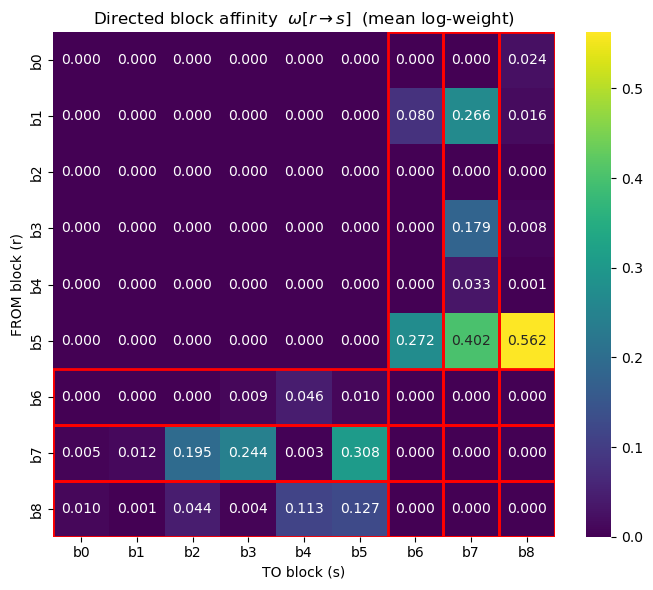

In [70]:
# Directed block-affinity matrix omega: mean log-weight FROM block r TO block s.
binv = np.array([blocks.index(block_of[r]) for r in regions_79])
B = len(blocks)

def block_mean_matrix(Wmat):
    om = np.zeros((B, B)); cn = np.zeros((B, B))
    for r in range(B):
        rmask = binv == r
        for s in range(B):
            cell = Wmat[np.ix_(rmask, binv == s)]
            om[r, s] = cell.sum(); cn[r, s] = cell.size
    return np.divide(om, cn, out=np.zeros_like(om), where=cn > 0)

omega = block_mean_matrix(W79)

plt.figure(figsize=(7, 6))
sns.heatmap(omega, annot=True, fmt='.3f', cmap='viridis',
            xticklabels=[f'b{b}' for b in blocks], yticklabels=[f'b{b}' for b in blocks])
plt.xlabel('TO block (s)'); plt.ylabel('FROM block (r)')
plt.title('Directed block affinity  $\\omega[r \\to s]$  (mean log-weight)')
hpc_pos = [blocks.index(h) for h in hpc_block_ids]
for hp in hpc_pos:                      # outline the HPC row & column
    plt.gca().add_patch(plt.Rectangle((0, hp), B, 1, fill=False, edgecolor='red', lw=2))
    plt.gca().add_patch(plt.Rectangle((hp, 0), 1, B, fill=False, edgecolor='red', lw=2))
plt.tight_layout(); plt.show()

### Reading ω for the central question

The **red-outlined row** of the HPC block is its **efferent / sending** profile
(`ω[HPC → s]`); the **red-outlined column** is its **afferent / receiving** profile
(`ω[s → HPC]`). The table below pairs them and reports the asymmetry
(`send − receive`) for every block:

- **positive** asymmetry → the hippocampus *drives* that block (sends more than it gets);
- **negative** asymmetry → that block *drives* the hippocampus (the HPC mostly receives);
- **near zero** → reciprocal.

In [71]:
for hb in hpc_block_ids:
    bi = blocks.index(hb)
    prof = pd.DataFrame({
        'HPC_sends_to (efferent)':     omega[bi, :],
        'HPC_receives_from (afferent)': omega[:, bi],
    }, index=[f'b{b}' for b in blocks])
    prof['asymmetry (send - receive)'] = prof.iloc[:, 0] - prof.iloc[:, 1]
    print(f'=== HPC block b{hb} ===')
    print(prof.round(4).to_string())
    print()

=== HPC block b6 ===
    HPC_sends_to (efferent)  HPC_receives_from (afferent)  asymmetry (send - receive)
b0                   0.0000                        0.0001                     -0.0001
b1                   0.0001                        0.0804                     -0.0803
b2                   0.0001                        0.0001                      0.0000
b3                   0.0091                        0.0003                      0.0088
b4                   0.0458                        0.0001                      0.0457
b5                   0.0097                        0.2723                     -0.2627
b6                   0.0000                        0.0000                      0.0000
b7                   0.0000                        0.0000                      0.0000
b8                   0.0000                        0.0000                      0.0000

=== HPC block b7 ===
    HPC_sends_to (efferent)  HPC_receives_from (afferent)  asymmetry (send - receive)
b0         

---
## Statistical test: is the send/receive asymmetry real?

We measure the overall asymmetry of the HPC block(s) as
`T = Σ_s (ω[HPC→s] − ω[s→HPC])²` and compare it to a **null** in which the *direction* of
every hippocampus-incident edge is randomly flipped (each HPC↔partner / HPC↔HPC edge has
its `i→j` and `j→i` weights swapped with probability ½). The consensus block labels are
held fixed.

**What this tests / what it does not.** It asks: *given these blocks, is the observed
directional asymmetry larger than expected if in/out labels were exchangeable?* It does
**not** re-infer the partition under the null — a full degree-preserving rewiring that
re-fits the SBM would be the stronger (and heavier) follow-up. Treat this as a first-pass
significance check, consistent with the bootstrapping pattern used elsewhere in the repo.

observed T = 0.3984 | null mean = 0.1721 | null 95% = 0.3949 | p = 0.0500


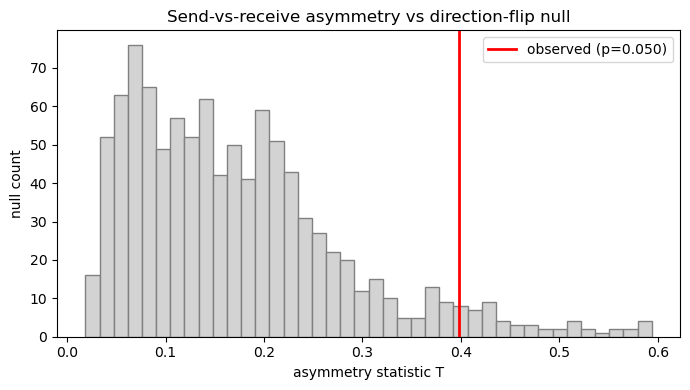

In [72]:
def asymmetry_stat(Wmat):
    M = block_mean_matrix(Wmat)
    return float(sum(np.sum((M[blocks.index(hb), :] - M[:, blocks.index(hb)]) ** 2)
                     for hb in hpc_block_ids))

T_obs = asymmetry_stat(W79)

hpc_pos_set = {regions_79.index(r) for r in hippocampal_regions}
inc_pairs = [(i, j) for i in range(79) for j in range(i + 1, 79)
             if i in hpc_pos_set or j in hpc_pos_set]

rng = np.random.default_rng(42)
N_PERM = 1000
null_T = np.empty(N_PERM)
for k in range(N_PERM):
    Wp = W79.copy()
    flip = rng.random(len(inc_pairs)) < 0.5
    for (i, j), f in zip(inc_pairs, flip):
        if f:
            Wp[i, j], Wp[j, i] = Wp[j, i], Wp[i, j]
    null_T[k] = asymmetry_stat(Wp)

p_val = (np.sum(null_T >= T_obs) + 1) / (N_PERM + 1)
print('observed T = %.4f | null mean = %.4f | null 95%% = %.4f | p = %.4f'
      % (T_obs, null_T.mean(), np.quantile(null_T, 0.95), p_val))

plt.figure(figsize=(7, 4))
plt.hist(null_T, bins=40, color='lightgray', edgecolor='gray')
plt.axvline(T_obs, color='red', lw=2, label=f'observed (p={p_val:.3f})')
plt.xlabel('asymmetry statistic T'); plt.ylabel('null count'); plt.legend()
plt.title('Send-vs-receive asymmetry vs direction-flip null'); plt.tight_layout(); plt.show()

---
## Seeing the implied profiles: block membership ↔ connectivity profiles

Earlier we hit a conceptual puzzle: the block-pair affinity is a `B × B` matrix, but a
**connectivity profile is a vector over many partners** — how do they fit together?

Under the SBM, every node's expected connectivity profile is *fully determined* by its
block label, every other node's block label, and ω. Concretely:

$$\mathbb{E}\big[\,W(i,\,j)\,\big] \;=\; \omega\big[\,\mathrm{block}(i),\;\mathrm{block}(j)\,\big]$$

So if we fill a 79×79 matrix with `ω[block(i), block(j)]` in every cell, we get the
**SBM's reconstruction of the connectome at block resolution** — a step function that
takes only `B × B` distinct values (one per block-pair).

This is the most concrete way to *see* what the SBM is asserting: every node's full
profile vector is a piecewise-constant version of the raw row — flat within each
partner-block, changing value only at block boundaries. Two nodes in the same block have
**identical** implied profiles by construction.

The plot below shows the raw log-weighted 79×79 alongside this model-implied matrix,
with regions reordered by block so the block-pair tiles appear as contiguous patches.

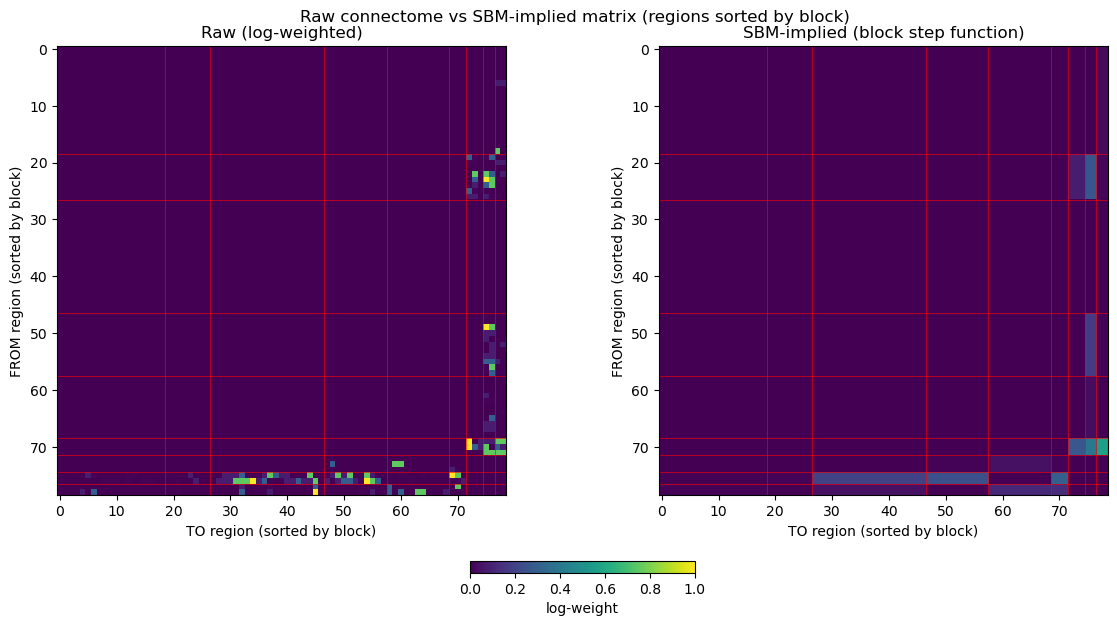

distinct values in raw     : 8
distinct values in implied : 36  (= B x B = 81)
Pearson r(raw, implied)    : 0.581
mean abs residual          : 0.0083


In [41]:
# Model-implied 79x79 matrix: each cell = omega[block(i), block(j)].
# This is the SBM's "reconstruction" -- a step function over block-pairs that takes
# only B*B distinct values (vs many in the raw matrix).
M_implied = omega[binv[:, None], binv[None, :]]

# Reorder rows/cols by block so block-pair tiles appear as contiguous patches.
order = np.argsort(binv, kind='stable')
W_sorted = W79[np.ix_(order, order)]
M_sorted = M_implied[np.ix_(order, order)]
binv_sorted = binv[order]
boundaries = np.where(np.diff(binv_sorted) != 0)[0] + 1

vmax = float(max(W_sorted.max(), M_sorted.max()))
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
for ax, M, title in zip(axes, [W_sorted, M_sorted],
                        ['Raw (log-weighted)', 'SBM-implied (block step function)']):
    im = ax.imshow(M, cmap='viridis', vmin=0, vmax=vmax, aspect='equal')
    ax.set_title(title)
    ax.set_xlabel('TO region (sorted by block)')
    ax.set_ylabel('FROM region (sorted by block)')
    for b in boundaries:
        ax.axhline(b - 0.5, color='red', lw=0.6, alpha=0.7)
        ax.axvline(b - 0.5, color='red', lw=0.6, alpha=0.7)
fig.colorbar(im, ax=axes, fraction=0.025, pad = 0.05, label='log-weight', location='bottom')
plt.suptitle('Raw connectome vs SBM-implied matrix (regions sorted by block)', y=1.02)
# plt.tight_layout()
plt.show()

print(f'distinct values in raw     : {len(np.unique(np.round(W79, 6)))}')
print(f'distinct values in implied : {len(np.unique(np.round(M_implied, 6)))}  (= B x B = {B * B})')
print(f'Pearson r(raw, implied)    : {np.corrcoef(W79.ravel(), M_implied.ravel())[0, 1]:.3f}')
print(f'mean abs residual          : {np.mean(np.abs(W79 - M_implied)):.4f}')

**How to read the comparison.**

- **Solid-colored tiles** in the implied matrix are the model's claim: every pair of
  regions in `(block r, block s)` shares the same expected weight `ω[r, s]`. The raw
  matrix should look like a noisier version of the same tiling.
- The **HPC band** (the contiguous block of rows/cols belonging to HPC) shows the
  hippocampus's compressed efferent/afferent profile — only as many distinct values as
  there are partner-blocks. The row-vs-column asymmetry there is the same send-vs-receive
  structure the previous section quantified.
- **Where raw and implied diverge** is the within-block variation the model treats as
  noise. Localised hot spots may flag regions that fit their assigned block poorly and
  could be worth inspecting individually.
- The printed statistics quantify the compression: the implied matrix has at most
  `B × B` distinct values vs many in the raw, yet (typically) still correlates strongly
  with it — that correlation is the "did the block compression actually capture the
  structure?" sanity check.

---
## Summary, caveats, and next steps

**What we did.** (1) A bipartite SBM grouped partner regions by their hippocampal
connectivity profile, separately for efferent and afferent connections, and we compared
the two groupings with AMI. (2) A directed 79×79 SBM modeled in- and out-flow jointly;
its asymmetric ω matrix gives the hippocampus's sending vs receiving profile directly, and
a direction-flip permutation test checks whether that asymmetry exceeds chance. (3) Finally, we visualized the **SBM-implied 79×79 matrix** alongside the raw to make the block-resolution compression directly visible.

**Caveats.**
- Partner↔partner edges are zeroed by construction, so all structure is HPC-centric.
- `real-exponential` is a reasonable but not the only choice for the weight model; the
  log-transform itself is one of several defensible weightings.
- The permutation null holds the partition fixed; a degree-preserving rewiring that
  re-fits the SBM is the stronger test.
- The HPC side has only 7 nodes, so HPC-block structure is necessarily coarse.

**Possible next steps.** nested SBM for hierarchical structure; a degree-preserving null
that re-infers blocks; repeating on per-animal matrices to check stability; and relating
the recovered blocks to anatomical major divisions (`label_major_division_mapping.csv`).

---
## Follow-up: separating block-pair *density* from *edge-mean*

The `omega` we used in the heatmap above conflates two things:

$$\omega_{rs} \;=\; \rho_{rs}\,\cdot\,\hat{\mu}_{rs}$$

- $\rho_{rs}$ = block-pair **density** = fraction of $(i \in r, j \in s)$ ordered pairs that actually have an edge.
- $\hat{\mu}_{rs}$ = block-pair **edge-mean** = mean log-weight averaged **over the edges that exist only** — this is the model's $\hat{\mu}_{rs}$ under the exponential weight component.

A small $\omega_{rs}$ can mean low density, low edge strength, or both — and those are different biological claims. For the central question:

- $\rho[\mathrm{HPC} \to s]$ low ⇒ the hippocampus *rarely* projects to block $s$ (few targets).
- $\hat{\mu}[\mathrm{HPC} \to s]$ low ⇒ when it does project there, the projections are *weak*.

The cell below plots all three matrices side-by-side and breaks the HPC send/receive table out by density vs edge-mean so the two contributions are legible separately.

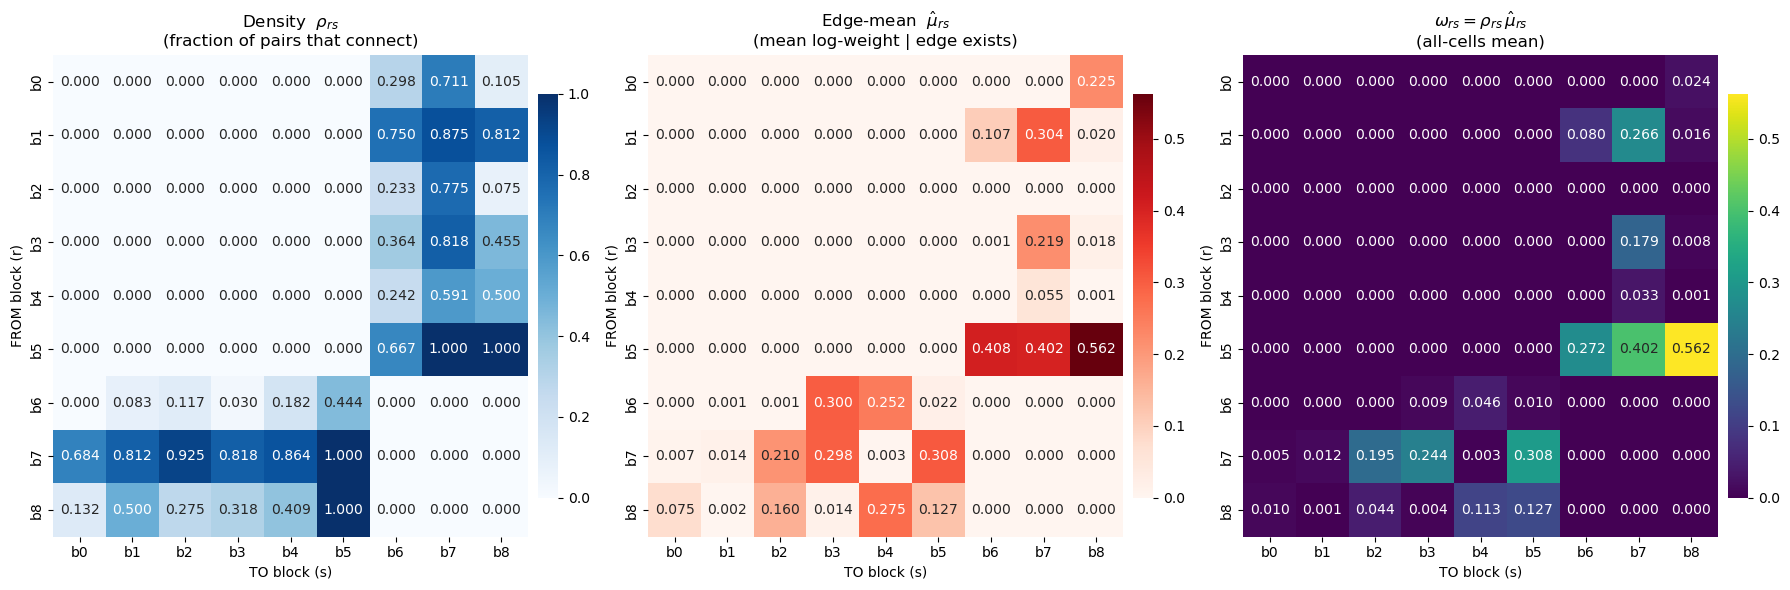

=== HPC block b6 ===
    send rho (HPC->s)  send mu  (HPC->s)  recv rho (s->HPC)  recv mu  (s->HPC)
b0             0.0000             0.0000             0.2982             0.0004
b1             0.0833             0.0010             0.7500             0.1072
b2             0.1167             0.0007             0.2333             0.0002
b3             0.0303             0.3000             0.3636             0.0008
b4             0.1818             0.2519             0.2424             0.0002
b5             0.4444             0.0217             0.6667             0.4085
b6             0.0000             0.0000             0.0000             0.0000
b7             0.0000             0.0000             0.0000             0.0000
b8             0.0000             0.0000             0.0000             0.0000

=== HPC block b7 ===
    send rho (HPC->s)  send mu  (HPC->s)  recv rho (s->HPC)  recv mu  (s->HPC)
b0             0.6842             0.0067             0.7105             0.0002
b1       

In [47]:
# Decompose omega[r,s] = rho[r,s] * mu_hat[r,s] (density * edge-mean).
rho = np.zeros((B, B))
mu  = np.zeros((B, B))
for r in range(B):
    rmask = binv == r
    for s in range(B):
        cell = W79[np.ix_(rmask, binv == s)]
        edges = cell > 0
        rho[r, s] = edges.mean()
        mu[r, s]  = cell[edges].mean() if edges.any() else 0.0

# Sanity check: rho * mu should reproduce the all-cells omega.
assert np.allclose(rho * mu, omega, atol=1e-10), 'decomposition mismatch'

labels = [f'b{b}' for b in blocks]
panels = [
    (rho,   r'Density  $\rho_{rs}$' '\n' r'(fraction of pairs that connect)',           'Blues'),
    (mu,    r'Edge-mean  $\hat{\mu}_{rs}$' '\n' r'(mean log-weight | edge exists)',     'Reds'),
    (omega, r'$\omega_{rs} = \rho_{rs}\,\hat{\mu}_{rs}$' '\n' r'(all-cells mean)',      'viridis'),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (M, title, cmap) in zip(axes, panels):
    sns.heatmap(M, annot=True, fmt='.3f', cmap=cmap,
                xticklabels=labels, yticklabels=labels, ax=ax,
                cbar_kws={'fraction': 0.04, 'pad': 0.02})
    ax.set_title(title); ax.set_xlabel('TO block (s)'); ax.set_ylabel('FROM block (r)')
plt.tight_layout(); plt.show()

# HPC send/receive table broken out by density vs edge-mean.
for hb in hpc_block_ids:
    bi = blocks.index(hb)
    df = pd.DataFrame({
        'send rho (HPC->s)':  rho[bi, :],
        'send mu  (HPC->s)':  mu[bi, :],
        'recv rho (s->HPC)':  rho[:, bi],
        'recv mu  (s->HPC)':  mu[:, bi],
    }, index=labels)
    print(f'=== HPC block b{hb} ===')
    print(df.round(4).to_string())
    print()

---
## Same null test, broken out by density vs edge-mean

The $\omega$-asymmetry null tested whether the *combined* $\omega = \rho \cdot \hat\mu$
matrix is asymmetric between HPC's send and receive sides. To say whether any such
asymmetry is one of **selectivity** ($\rho$) or **strength** ($\hat\mu$) — or both — we
rerun the **identical** direction-flip permutation (same RNG seed → same shuffles) but
compute the asymmetry statistic separately on $\rho$ and $\hat\mu$:

$$T_{\rho} \;=\; \sum_{b \in \text{HPC blocks}} \sum_s \big(\rho[b,s] - \rho[s,b]\big)^2
\qquad
T_{\hat\mu} \;=\; \sum_{b \in \text{HPC blocks}} \sum_s \big(\hat\mu[b,s] - \hat\mu[s,b]\big)^2$$

How to read the two p-values:

- **Small $p_{\rho}$ only** → asymmetry is one of *selectivity*: HPC connects to a
  different *set* of partners than connect back, but the connections themselves aren't
  differentially strong.
- **Small $p_{\hat\mu}$ only** → asymmetry is one of *strength*: HPC reaches roughly the
  same partners in both directions, but the outgoing connections are stronger (or weaker)
  than the incoming ones.
- **Both small** → both contribute to the $\omega$-asymmetry.

(Same caveat as before: the partition is held fixed, so this tests asymmetry *given the
blocks*. A null that re-infers blocks under direction-flipped data is the stronger
follow-up.)

DENSITY    rho    : T_obs = 0.9779 | null mean = 0.2098 | 95% = 0.3523 | p = 0.0010
EDGE-MEAN  mu_hat : T_obs = 0.7726  | null mean = 0.3044  | 95% = 0.5582  | p = 0.0040


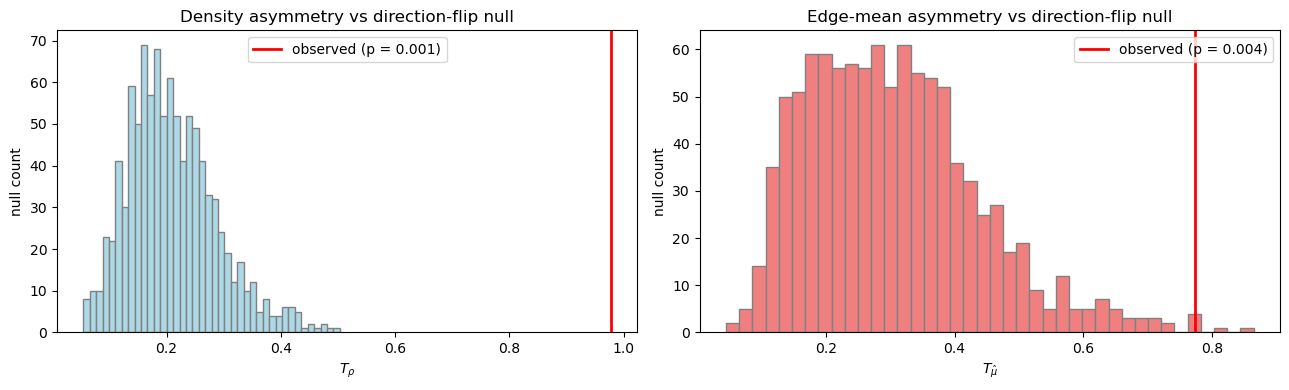

In [43]:
# Same direction-flip null as the omega test, but the asymmetry statistic is computed
# separately on rho (density) and mu_hat (edge-mean) to localize where any asymmetry sits.

def block_rho_mu(Wmat):
    rho_ = np.zeros((B, B))
    mu_  = np.zeros((B, B))
    for r in range(B):
        rmask = binv == r
        for s in range(B):
            cell = Wmat[np.ix_(rmask, binv == s)]
            edges = cell > 0
            rho_[r, s] = edges.mean()
            mu_[r, s]  = cell[edges].mean() if edges.any() else 0.0
    return rho_, mu_

def asym_T(M):
    T = 0.0
    for hb in hpc_block_ids:
        bi = blocks.index(hb)
        T += float(np.sum((M[bi, :] - M[:, bi]) ** 2))
    return T

# Observed values (on the raw matrix at the fixed consensus blocks).
rho_obs, mu_obs = block_rho_mu(W79)
T_rho_obs = asym_T(rho_obs)
T_mu_obs  = asym_T(mu_obs)

# Same direction-flip null, same seed as the omega test => identical shuffles.
rng = np.random.default_rng(42)
N_PERM = 1000
null_T_rho = np.empty(N_PERM)
null_T_mu  = np.empty(N_PERM)
for k in range(N_PERM):
    Wp = W79.copy()
    flip = rng.random(len(inc_pairs)) < 0.5
    for (i, j), f in zip(inc_pairs, flip):
        if f:
            Wp[i, j], Wp[j, i] = Wp[j, i], Wp[i, j]
    rho_p, mu_p = block_rho_mu(Wp)
    null_T_rho[k] = asym_T(rho_p)
    null_T_mu[k]  = asym_T(mu_p)

p_rho = (np.sum(null_T_rho >= T_rho_obs) + 1) / (N_PERM + 1)
p_mu  = (np.sum(null_T_mu  >= T_mu_obs)  + 1) / (N_PERM + 1)

print(f'DENSITY    rho    : T_obs = {T_rho_obs:.4f} | null mean = {null_T_rho.mean():.4f}'
      f' | 95% = {np.quantile(null_T_rho, 0.95):.4f} | p = {p_rho:.4f}')
print(f'EDGE-MEAN  mu_hat : T_obs = {T_mu_obs:.4f}  | null mean = {null_T_mu.mean():.4f}'
      f'  | 95% = {np.quantile(null_T_mu, 0.95):.4f}  | p = {p_mu:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(null_T_rho, bins=40, color='lightblue', edgecolor='gray')
axes[0].axvline(T_rho_obs, color='red', lw=2, label=f'observed (p = {p_rho:.3f})')
axes[0].set_title('Density asymmetry vs direction-flip null')
axes[0].set_xlabel(r'$T_\rho$'); axes[0].set_ylabel('null count'); axes[0].legend()
axes[1].hist(null_T_mu, bins=40, color='lightcoral', edgecolor='gray')
axes[1].axvline(T_mu_obs, color='red', lw=2, label=f'observed (p = {p_mu:.3f})')
axes[1].set_title('Edge-mean asymmetry vs direction-flip null')
axes[1].set_xlabel(r'$T_{\hat\mu}$'); axes[1].set_ylabel('null count'); axes[1].legend()
plt.tight_layout(); plt.show()

---
## Part 3 — Full 79×79 SBM (nothing zeroed)

Parts 1–2 **masked** the network: Part 2 zeroed the partner↔partner block *and* the
HPC↔HPC block, so every surviving edge touched the hippocampus and the recovered blocks
were HPC-centric **by construction**. That masking is a strong assumption, not a neutral
choice.

Here we relax it completely. We fit the **same directed, weighted, `real-exponential`
SBM on the full 79×79 submatrix with all connections intact** — partner↔partner target
interconnections *and* intrinsic HPC↔HPC connectivity included. The block structure is
now free to reflect whatever organization dominates the subnetwork, hippocampal or not.

**Why this is worth doing.** Comparing this partition to Part 2's shows how much the
zeroing shaped the earlier result:

- If the 7 HPC subregions still cluster the same way (high AMI vs Part 2), the
  send/receive organization is **robust** to including background connectivity.
- If they dissolve into partner-driven blocks (low AMI), the earlier structure depended
  on the mask — the partner↔partner edges carry enough signal to reorganize everything.

Everything below uses fresh variable names (`*_full`) so Part 2's objects are left intact.

In [ ]:
# Full 79x79: keep ALL connections (partner<->partner and HPC<->HPC left intact).
# Same 79 nodes and same directed convention as Part 2; the only difference is NO zeroing.
sub_full = df_average.loc[regions_79, regions_79].copy().fillna(0.0)
print('79x79 full matrix:', sub_full.shape)
print('non-zero entries kept:', int((sub_full.values > 0).sum()),
      f'(vs {int((W79 > 0).sum())} in the HPC-masked Part 2)')

# The averaged connectome carries a single non-integer entry (5.5) in the partner<->partner
# block -- Part 2 never saw it because that block was zeroed. log_weight_transform requires
# integer ordinals 0-7, so round to the nearest ordinal first (here: 1 edge, changed by <=0.5).
sub_full_int = np.round(sub_full.values).astype(int)
n_rounded = int((np.abs(sub_full.values - sub_full_int) > 1e-9).sum())
print(f'rounded {n_rounded} non-integer entr{"y" if n_rounded == 1 else "ies"} to nearest ordinal')

# Ordinal 0-7 -> log-weighted, direction preserved (entry [i,j] = FROM i TO j).
W79_full = log_weight_transform(sub_full_int)

g79_full = build_directed_graph(W79_full, regions_79)
print('directed?', g79_full.is_directed(), '|',
      g79_full.num_vertices(), 'nodes,', g79_full.num_edges(), 'edges')

state79_full, b79_full, pv79_full, pm79_full = fit_sbm_consensus(g79_full)
blocks_full = sorted({int(b79_full[v]) for v in g79_full.vertices()})
print('inferred blocks:', len(blocks_full))

### Block membership, and how much the mask mattered

We tabulate each region's consensus block (flagging the HPC subregions), then quantify
how different this full-matrix partition is from Part 2's HPC-masked one over the same 79
nodes using **Adjusted Mutual Information** (1.0 = identical grouping, ~0 = chance).

In [ ]:
block_of_full = {g79_full.vp['name'][v]: int(b79_full[v]) for v in g79_full.vertices()}
assign_full = (pd.DataFrame({'region': list(block_of_full), 'block': list(block_of_full.values())})
                 .assign(is_hpc=lambda d: d.region.isin(hippocampal_regions))
                 .sort_values(['block', 'is_hpc'], ascending=[True, False]))

hpc_block_ids_full = sorted(assign_full.loc[assign_full.is_hpc, 'block'].unique().tolist())
print('HPC subregions fall in block(s):', hpc_block_ids_full)
print(assign_full[assign_full.is_hpc].to_string(index=False))
print('\nblock sizes:')
print(assign_full.groupby('block').size().rename('n_regions'))

# How much did keeping partner<->partner (and HPC<->HPC) edges change the partition?
# AMI over the same 79 nodes: Part 2 (HPC-masked) vs Part 3 (full).
labels_masked = [block_of[r]      for r in regions_79]   # block_of from Part 2
labels_full   = [block_of_full[r] for r in regions_79]
ami_full_vs_masked = adjusted_mutual_info_score(labels_masked, labels_full)
print(f'\nAMI(Part 2 masked partition, Part 3 full partition) = {ami_full_vs_masked:.3f}')

In [ ]:
# Directed block-affinity omega (mean log-weight FROM block r TO block s) for the full model.
# Self-contained (takes binv/B as args) so it doesn't touch Part 2's globals.
binv_full = np.array([blocks_full.index(block_of_full[r]) for r in regions_79])
B_full = len(blocks_full)

def block_mean_matrix_of(Wmat, binv_, B_):
    om = np.zeros((B_, B_)); cn = np.zeros((B_, B_))
    for r in range(B_):
        rmask = binv_ == r
        for s in range(B_):
            cell = Wmat[np.ix_(rmask, binv_ == s)]
            om[r, s] = cell.sum(); cn[r, s] = cell.size
    return np.divide(om, cn, out=np.zeros_like(om), where=cn > 0)

omega_full = block_mean_matrix_of(W79_full, binv_full, B_full)

# Left: omega heatmap (HPC row/col outlined). Right: raw log-weighted adjacency, block-sorted.
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

sns.heatmap(omega_full, annot=True, fmt='.3f', cmap='viridis', ax=axes[0],
            xticklabels=[f'b{b}' for b in blocks_full],
            yticklabels=[f'b{b}' for b in blocks_full],
            cbar_kws={'fraction': 0.045, 'pad': 0.02})
axes[0].set_xlabel('TO block (s)'); axes[0].set_ylabel('FROM block (r)')
axes[0].set_title(r'Full 79x79 block affinity  $\omega[r \to s]$  (nothing zeroed)')
for hp in [blocks_full.index(h) for h in hpc_block_ids_full]:   # outline HPC row & column
    axes[0].add_patch(plt.Rectangle((0, hp), B_full, 1, fill=False, edgecolor='red', lw=2))
    axes[0].add_patch(plt.Rectangle((hp, 0), 1, B_full, fill=False, edgecolor='red', lw=2))

order_full = np.argsort(binv_full, kind='stable')
W_sorted_full = W79_full[np.ix_(order_full, order_full)]
boundaries_full = np.where(np.diff(binv_full[order_full]) != 0)[0] + 1
axes[1].imshow(W_sorted_full, cmap='viridis', vmin=0, vmax=float(W79_full.max()), aspect='equal')
axes[1].set_title('Raw log-weighted 79x79 (sorted by block)')
axes[1].set_xlabel('TO region (sorted by block)'); axes[1].set_ylabel('FROM region (sorted by block)')
for b in boundaries_full:
    axes[1].axhline(b - 0.5, color='red', lw=0.6, alpha=0.7)
    axes[1].axvline(b - 0.5, color='red', lw=0.6, alpha=0.7)

plt.tight_layout(); plt.show()

### Reading Part 3

- **Block count / sizes.** With the partner↔partner block now populated, the model has
  ~25× more edges to explain, so it typically infers a *different* (often finer) block
  structure than the masked Part 2 — driven partly by how the target regions
  interconnect among themselves, not just their hippocampal links.
- **HPC membership + AMI.** If the HPC subregions stay grouped as in Part 2 and the AMI is
  high, the hippocampal send/receive organization survives the inclusion of background
  connectivity. A low AMI means the mask was doing the heavy lifting in Parts 1–2.
- **ω heatmap.** Off-HPC blocks now carry real affinity (they are no longer zeroed), so
  the HPC row/column is one part of a richer chart rather than the whole story. The
  red-outlined HPC row (efferent) vs column (afferent) can still be compared for
  send-vs-receive asymmetry, but now *in the context of* the surrounding target network.

> Caveat: this is still the directed `real-exponential` weighted SBM with an MCMC
> consensus — only the input mask changed. It is the natural control for "how much did
> zeroing the partner↔partner block shape the earlier result?" and complements, rather
> than replaces, the HPC-centric Parts 1–2.

---
---
# ============================================================
#   full_efferent / full_afferent: directional masks that KEEP partner-partner
# ============================================================

Two more directed SBMs, both starting from the **full** log-weighted 79×79 matrix and —
unlike Part 2 — **keeping the partner↔partner target interconnections intact**. We only
strip the hippocampus-incident edges in one direction:

- **full_efferent**: zero every connection **TO** the hippocampus (afferent) and every
  within-HPC edge → keeps **HPC → partner** and **partner ↔ partner**.
- **full_afferent**: zero every connection **FROM** the hippocampus (efferent) and every
  within-HPC edge → keeps **partner → HPC** and **partner ↔ partner**.

So each graph isolates one hippocampal direction *against the full cortical/subcortical
background*, rather than the HPC-only network of Part 2. We fit the same directed,
weighted (`real-exponential`) SBM with MCMC consensus to each.

> Runtime: two full SBM fits (~1-2 min each).

In [52]:
# Full log-weighted 79x79 (nothing zeroed yet). Round the single non-integer entry
# (5.5, in the partner<->partner block) so log_weight_transform accepts it.
sub_full = df_average.loc[regions_79, regions_79].copy().fillna(0.0)
W_full = log_weight_transform(np.round(sub_full.values).astype(int))
W_full_df = pd.DataFrame(W_full, index=regions_79, columns=regions_79)

# full_efferent: zero all connections TO hippocampus (HPC columns) + within-HPC.
eff_df = W_full_df.copy()
eff_df.loc[:, hippocampal_regions] = 0.0
eff_df.loc[hippocampal_regions, hippocampal_regions] = 0.0

# full_afferent: zero all connections FROM hippocampus (HPC rows) + within-HPC.
aff_df = W_full_df.copy()
aff_df.loc[hippocampal_regions, :] = 0.0
aff_df.loc[hippocampal_regions, hippocampal_regions] = 0.0

print('full_efferent edges:', int((eff_df.values > 0).sum()),
      '(HPC->partner + partner<->partner)')
print('full_afferent edges:', int((aff_df.values > 0).sum()),
      '(partner->HPC + partner<->partner)')

# Same directed weighted SBM (MDL + MCMC consensus) on each graph.
g_eff_full = build_directed_graph(eff_df.values, regions_79)
g_aff_full = build_directed_graph(aff_df.values, regions_79)

state_eff_f, b_eff_f, pv_eff_f, pm_eff_f = fit_sbm_consensus(g_eff_full)
state_aff_f, b_aff_f, pv_aff_f, pm_aff_f = fit_sbm_consensus(g_aff_full)

blocks_eff_f = sorted({int(b_eff_f[v]) for v in g_eff_full.vertices()})
blocks_aff_f = sorted({int(b_aff_f[v]) for v in g_aff_full.vertices()})
print(f'\nfull_efferent: inferred {len(blocks_eff_f)} blocks'
      f'  |  full_afferent: inferred {len(blocks_aff_f)} blocks\n')

# Which block(s) hold the HPC subregions in each?
for tag, g, b in [('full_efferent', g_eff_full, b_eff_f), ('full_afferent', g_aff_full, b_aff_f)]:
    hpc_blocks = sorted({int(b[v]) for v in g.vertices()
                         if g.vp['name'][v] in hippocampal_regions})
    print(f'{tag}: HPC subregions fall in block(s) {hpc_blocks}')

# Per-block region listings (reuses print_directed_blocks from Part 2).
print()
print_directed_blocks(g_eff_full, b_eff_f,
    f'FULL EFFERENT  (HPC->partner + partner<->partner)  -  {len(blocks_eff_f)} blocks')
print('\n')
print_directed_blocks(g_aff_full, b_aff_f,
    f'FULL AFFERENT  (partner->HPC + partner<->partner)  -  {len(blocks_aff_f)} blocks')

full_efferent edges: 2721 (HPC->partner + partner<->partner)
full_afferent edges: 2767 (partner->HPC + partner<->partner)

full_efferent: inferred 25 blocks  |  full_afferent: inferred 23 blocks

full_efferent: HPC subregions fall in block(s) [2, 6, 8, 9, 16, 18]
full_afferent: HPC subregions fall in block(s) [6, 9, 12, 13, 15]

FULL EFFERENT  (HPC->partner + partner<->partner)  -  25 blocks

Block b0  (n = 3)
    SI, MS, NDB

Block b1  (n = 2)
    BSTam, BSTtr

Block b2  (n = 4)   <-- contains HPC: CA2
    BSTju, BSTpr, BLAa, CA2

Block b3  (n = 2)
    BSTif, LHAjvv

Block b4  (n = 2)
    BSTd, PAA

Block b5  (n = 3)
    LSr.m.v, LSr.dl, PVT

Block b6  (n = 3)   <-- contains HPC: SUBv
    LSr.m.d, MEAad, SUBv

Block b7  (n = 2)
    LSr.vl, LHAjd

Block b8  (n = 6)   <-- contains HPC: DG, CA1d
    LSc.v, LSc.d, SF, IAM, DG, CA1d

Block b9  (n = 3)   <-- contains HPC: CA3
    LSv, MPNm, CA3

Block b10  (n = 4)
    AAA, COApm, COApl, BMAa

Block b11  (n = 3)
    MEApv, MEApd, SMT

Block 

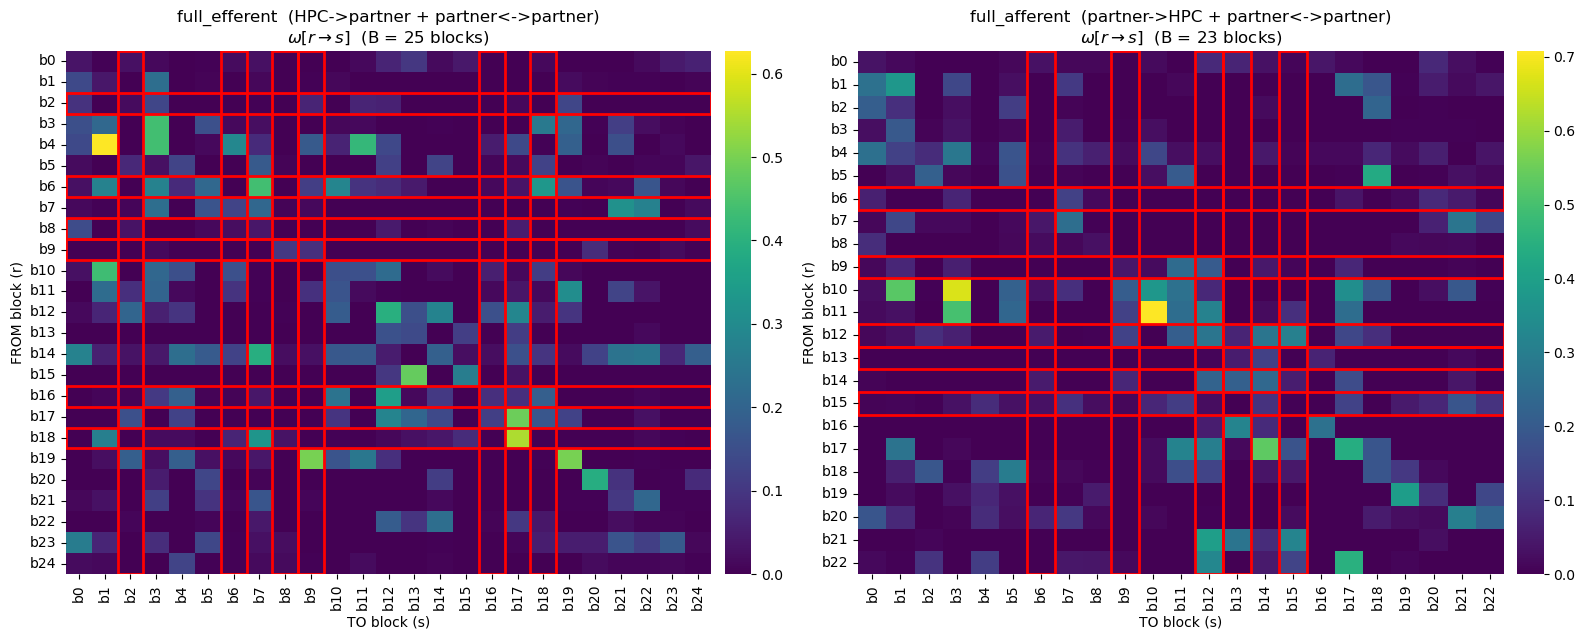

In [53]:
# Block-affinity omega (mean log-weight FROM block r TO block s) for the two full-background
# fits, laid out like Part 2/3. Reuses block_mean_matrix_of from Part 3; HPC row/col outlined.
def _binv_of(g, b, blocks):
    return np.array([blocks.index(int(b[v])) for v in g.vertices()])

def _hpc_positions(g, b, blocks):
    hpc_blocks = sorted({int(b[v]) for v in g.vertices()
                         if g.vp['name'][v] in hippocampal_regions})
    return [blocks.index(h) for h in hpc_blocks]

binv_eff_f = _binv_of(g_eff_full, b_eff_f, blocks_eff_f)
binv_aff_f = _binv_of(g_aff_full, b_aff_f, blocks_aff_f)
omega_eff_f = block_mean_matrix_of(eff_df.values, binv_eff_f, len(blocks_eff_f))
omega_aff_f = block_mean_matrix_of(aff_df.values, binv_aff_f, len(blocks_aff_f))

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, omega, g, b, blocks, title in [
    (axes[0], omega_eff_f, g_eff_full, b_eff_f, blocks_eff_f,
     'full_efferent  (HPC->partner + partner<->partner)'),
    (axes[1], omega_aff_f, g_aff_full, b_aff_f, blocks_aff_f,
     'full_afferent  (partner->HPC + partner<->partner)'),
]:
    B = len(blocks)
    sns.heatmap(omega, annot=(B <= 12), fmt='.3f', cmap='viridis', ax=ax,
                xticklabels=[f'b{bb}' for bb in blocks],
                yticklabels=[f'b{bb}' for bb in blocks],
                cbar_kws={'fraction': 0.045, 'pad': 0.02})
    ax.set_xlabel('TO block (s)'); ax.set_ylabel('FROM block (r)')
    ax.set_title(f'{title}\n' r'$\omega[r \to s]$  ' f'(B = {B} blocks)')
    for hp in _hpc_positions(g, b, blocks):     # outline the HPC row & column
        ax.add_patch(plt.Rectangle((0, hp), B, 1, fill=False, edgecolor='red', lw=2))
        ax.add_patch(plt.Rectangle((hp, 0), 1, B, fill=False, edgecolor='red', lw=2))
plt.tight_layout(); plt.show()

---
## Description length of the directed 79×79 SBMs

Same idea as the bipartite MDL cell: `BlockState.entropy()` is the description length, and we
evaluate it at each **consensus partition** (rebuilding the state, since MCMC moved the
originals). This covers every directed 79×79 fit in the notebook — Part 2 (masked), Part 3
(full), and the `full_efferent` / `full_afferent` graphs. No `pclabel` here (these are
unconstrained directed models). Cells you haven't run are reported as `not run`.

In [73]:
def directed_dl(g, b):
    # Description length (nats) of partition b on directed weighted graph g.
    return gt.BlockState(g, b=b, recs=[g.ep['weight']], rec_types=['real-exponential']).entropy()

rows = []
for label, gname, bname in [
    ('Part 2: masked 79x79',                             'g79',       'b79'),
    ('Part 3: full 79x79 (nothing zeroed)',              'g79_full',  'b79_full'),
    ('full_efferent (HPC->partner + partner<->partner)', 'g_eff_full', 'b_eff_f'),
    ('full_afferent (partner->HPC + partner<->partner)', 'g_aff_full', 'b_aff_f'),
]:
    if gname in globals() and bname in globals():
        g, b = globals()[gname], globals()[bname]
        B = len(set(int(b[v]) for v in g.vertices()))
        rows.append([label, g.num_vertices(), g.num_edges(), B, round(directed_dl(g, b), 3)])
    else:
        rows.append([label, None, None, None, 'not run'])

print(pd.DataFrame(rows, columns=['fit', 'nodes', 'edges', 'B', 'description_length'])
        .to_string(index=False))

                                             fit  nodes  edges  B  description_length
                            Part 2: masked 79x79     79    416  9            -286.399
             Part 3: full 79x79 (nothing zeroed)     79   2976 26           -2624.436
full_efferent (HPC->partner + partner<->partner)     79   2721 25           -2386.053
full_afferent (partner->HPC + partner<->partner)     79   2767 23           -2664.557


### Comparing afferent vs efferent projection DL within the 79×79 graph

Raw description lengths are **not** directly comparable between the two directions: the
afferent block has ~231 edges vs ~185 efferent, description length grows with the amount of
data, and the continuous `real-exponential` weight model can even make DL negative (it
carries a differential-entropy term). Holding the *joint* 79×79 partition fixed and splitting
by direction is also unsatisfying — that partition is optimized for both directions at once
and can describe one direction worse than a single block would.

A fair, size-normalized comparison is **how many nats the block structure saves relative to a
no-structure (single-block) baseline, per edge**. For each direction we (1) extract its edges
from the 79×79 (efferent = HPC→partner, afferent = partner→HPC), (2) fit an SBM (MDL point
estimate) and record its DL, (3) record the single-block (`B=1`) DL of the same edges, and
(4) report `(DL_null − DL_fit) / n_edges`. Each direction gets its **own** optimal blocks, so
this measures how much block structure each projection carries on its own; a larger value =
more structure per edge.

In [74]:
nP = len(partner_regions)     # regions_79 = partners (0..nP-1) then HPC (nP..78)

W_eff_proj = np.zeros_like(W79); W_eff_proj[nP:, :nP] = W79[nP:, :nP]   # HPC -> partner
W_aff_proj = np.zeros_like(W79); W_aff_proj[:nP, nP:] = W79[:nP, nP:]   # partner -> HPC

def projection_compression(Wsub, labels):
    g = build_directed_graph(Wsub, labels)
    st = gt.minimize_blockmodel_dl(
        g, state_args=dict(recs=[g.ep['weight']], rec_types=['real-exponential']))
    dl_fit = st.entropy()
    b1 = np.zeros(g.num_vertices(), dtype=int)      # single-block (no structure) baseline
    dl_null = gt.BlockState(g, b=b1, recs=[g.ep['weight']],
                            rec_types=['real-exponential']).entropy()
    E = g.num_edges()
    return {'edges': E, 'B_fit': st.get_nonempty_B(), 'DL_fit': dl_fit, 'DL_null': dl_null,
            'nats_saved': dl_null - dl_fit, 'nats_saved_per_edge': (dl_null - dl_fit) / E}

comp = {'efferent (HPC->partner)': projection_compression(W_eff_proj, regions_79),
        'afferent (partner->HPC)': projection_compression(W_aff_proj, regions_79)}
tab = pd.DataFrame(comp).T
print(tab.round(3).to_string())
print('\n--> larger nats_saved_per_edge = more block structure per edge in that direction')
print('   efferent: %.3f   afferent: %.3f'
      % (comp['efferent (HPC->partner)']['nats_saved_per_edge'],
         comp['afferent (partner->HPC)']['nats_saved_per_edge']))

                         edges  B_fit   DL_fit  DL_null  nats_saved  nats_saved_per_edge
efferent (HPC->partner)  185.0    5.0   12.664  170.958     158.294                0.856
afferent (partner->HPC)  231.0    7.0 -298.913  136.129     435.043                1.883

--> larger nats_saved_per_edge = more block structure per edge in that direction
   efferent: 0.856   afferent: 1.883
